In [ ]:
from datasets import load_dataset, Dataset, load_from_disk
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print as pprint
import numpy as np
import re
from openai import OpenAI

import warnings
warnings.filterwarnings('ignore')

# Data

In [2]:
ds = load_dataset("greengerong/leetcode")['train']

In [3]:
prompts = []
language = []

keep = 100

for l in ['java', 'c++', 'python', 'javascript']:
    for i in tqdm(range(min(keep, len(ds)))):
        prompts.append(ds[i][l].split('```')[1])
        language.append(l)

language = np.array(language)

100%|██████████| 100/100 [00:00<00:00, 24732.02it/s]


# Model

In [4]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '0'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [5]:
model_name = 'llama'

if (model_name == 'llama'):

    tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct")
    model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", torch_dtype=torch.bfloat16).to(device)

    model = model.eval()

elif (model_name == 'gemma'):

    tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-9b-it")
    model = AutoModelForCausalLM.from_pretrained("google/gemma-2-9b-it", torch_dtype=torch.bfloat16).to(device)

    model = model.eval()


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  6.84it/s]


# Hidden states

In [6]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    hooks.append(layer.self_attn.register_forward_hook(get_activation(i)))

In [7]:
hidden_states = []

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.inference_mode():
        with torch.no_grad():
            inputs = tokenizer(p, return_tensors="pt").input_ids
            outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 448: 100%|██████████| 400/400 [00:20<00:00, 19.24it/s] 


## Attractors

In [8]:
target_layers = [i for i in range(len(model.model.layers))]
all_prompts_attractors = hidden_states

In [9]:
attractors = {l: {} for l in ['java', 'c++', 'python', 'javascript']}

for target_layer in target_layers:
    for l in ['java', 'c++', 'python', 'javascript']:

        cur_attractors = []
        for i in range(len(all_prompts_attractors)):
            if (language[i] != l):
                continue
            cur_attractors.append(all_prompts_attractors[i][target_layer])

        cur_attractors = torch.stack(cur_attractors, dim=0)

        attractors[l][target_layer] = torch.mean(cur_attractors, dim=0)

### Cosine Similarity

In [10]:

if (model_name == 'llama'):
    target_layer = 19
elif (model_name == 'gemma'):
    target_layer = 32

In [11]:
dis = np.zeros((len(prompts), len(prompts)))
cs = np.zeros((len(prompts), len(prompts)))

cs_func = nn.CosineSimilarity(dim=-1)

for i in range(len(prompts)):
    for j in range(len(prompts)):
        dis[i, j] = torch.linalg.norm(all_prompts_attractors[i][target_layer] - all_prompts_attractors[j][target_layer])
        cs[i, j] = cs_func(all_prompts_attractors[i][target_layer], all_prompts_attractors[j][target_layer])

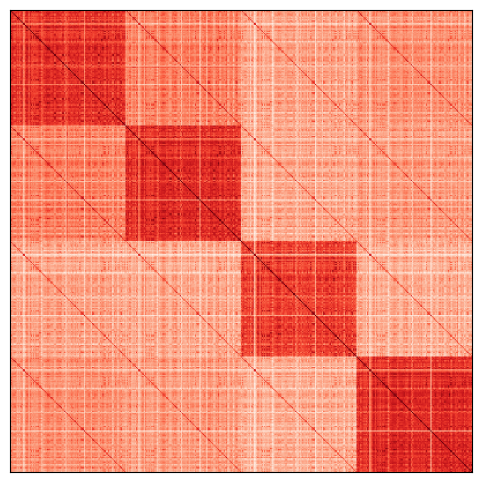

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(cs, cmap='Reds')
plt.xticks([])
plt.yticks([])
plt.show()

### t-sne

In [13]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (4, 3)

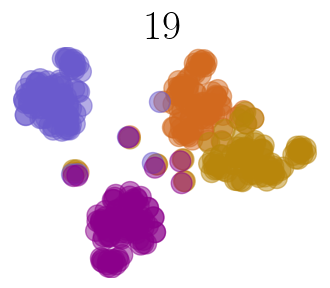

In [14]:
colors = []
for i in range(len(all_prompts_attractors)):
    if (language[i] == 'python'):
        colors.append('slateblue')
    if (language[i] == 'c++'):
        colors.append('darkgoldenrod')
    if (language[i] == 'java'):
        colors.append('chocolate')
    if (language[i] == 'javascript'):
        colors.append('darkmagenta')


cur_attractors = []
for i in range(len(prompts)):
    cur_attractors.append(all_prompts_attractors[i][target_layer])
cur_attractors = torch.stack(cur_attractors, dim=0).squeeze()

cur_attractors_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=20, random_state=0).fit_transform(cur_attractors.detach().cpu().float().numpy())

plt.scatter(cur_attractors_emb[:, 0], cur_attractors_emb[:, 1], c=colors, alpha=0.5)
plt.xticks([])
plt.yticks([])
plt.title(target_layer)
plt.show()

# Transpiler

In [15]:
for hook in hooks:
    hook.remove()

In [16]:
target_language = 'javascript'
strength = 1

def change_behavior(target_layer):
    def hook(model, input, output):
        output = (output[0] + strength*attractors[target_language][target_layer].to(device), *output[1:])
        return output
    return hook

hook = model.model.layers[target_layer].self_attn.register_forward_hook(change_behavior(target_layer))

In [17]:
def extract_program(prompt, target_language, source_language):

    if (target_language == 'c++'):
        target_language = 'cpp' 

    splits = re.split(r'\b' + target_language, prompt)[1:]

    for i in range(len(splits)):
        splits[i] = re.split(r'```', splits[i])[0].strip()
    
    for i in range(len(splits)):
        if (len(splits[i]) > 30):
            return splits[i]
        

    splits = re.split(r'\b' + '%s|%s' %(target_language, source_language), prompt)[1:]

    for i in range(len(splits)):
        splits[i] = re.split(r'```', splits[i])[0].strip()
    
    for i in range(len(splits)):
        if (len(splits[i]) > 30):
            return splits[i]

    return ''


## No steering

In [18]:
python_task = ds[300]['python']
js_task = ds[300]['javascript']
cpp_task = ds[300]['c++']
java_task = ds[300]['java']

prompt = f"Re-state the following program. "
prompt += f"Do not include an explanation.\n\n```{python_task}```"

In [21]:
target_language = 'javascript'

print ('No steering...\n')

strength = 0

with torch.inference_mode():
    with torch.no_grad():
        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=inputs.shape[1], 
                                    do_sample=False, top_k=20, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
        output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]

print ('-------------------------------------------------')
print (output_text)

No steering...

-------------------------------------------------
python
```python
from collections import deque

def shortestDistance(grid: list[list[int]]) -> int:
    m, n = len(grid), len(grid[0])

    total_count = [[0] * n for _ in range(m)]
    dist_sum = [[0] * n for _ in range(m)]
    house_count = 0

    dirs = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    for i in range(m):
        for j in range(n):
            if grid[i][j] == 1:
                house_count += 1
                q = deque([(i, j)])
                visited = [[False] * n for _ in range(m)]
                level = 1
                while q:
                    for _ in range(len(q)):
                        x, y = q.popleft()
                        for dx, dy in dirs:
                            x_new, y_new = x + dx, y + dy
                            if 0 <= x_new < m and 0 <= y_new < n and not visited[x_new][y_new] and grid[x_new][y_new] == 0:
                                visited[x_new][y_new] = True
       

## Steering

In [22]:
target_language = 'javascript'

print ('Steering...\n')

strength = 6

with torch.inference_mode():
    with torch.no_grad():
        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=inputs.shape[1], 
                                    do_sample=False, top_k=20, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
        output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]

print ('-------------------------------------------------')
print (output_text)

Steering...

-------------------------------------------------
python
    ```javascript
function shortestDistance(grid) {
    const m = grid.length;
    const n = grid[0].length;
    const total_count = Array(m).fill(0).map(() => Array(n).fill(0));
    const dist_sum = Array(m).fill(0).map(() => Array(n).fill(0));
    let house_count = 0;

    const dirs = [[1, 0], [-1, 0], [0, 1], [0, -1]];

    for (let i = 0; i < m; i++) {
        for (let j = 0; j < n; j++) {
            if (grid[i][j] === 1) {
                house_count++;
                const q = [[i, j]];
                const visited = Array(m).fill(0).map(() => Array(n).fill(0));
                let level = 1;
                while (q.length) {
                    for (let k = 0; k < q.length; k++) {
                        const [x, y] = q.shift();
                        for (const [dx, dy] of dirs) {
                            const x_new = x + dx;
                            const y_new = y + dy;
                       